<a class="anchor" id="0"></a>
# **Segmentez des clients d'un site e-commerce**


Contexte :

Olist est une entreprise brésilienne qui propose une solution de vente sur les marketplaces en ligne. Cette entreprise souhaite que vous fournissiez à ses équipes d'e-commerce une segmentation des clients qu’elles pourront utiliser au quotidien pour leurs campagnes de communication.Vous devrez fournir à l’équipe marketing une description de votre segmentation et de sa logique sous-jacente pour une utilisation optimale, ainsi qu’une proposition de contrat de maintenance basée sur une analyse de la stabilité des segments au cours du temps.

Mission :

La mission consiste à aider les équipes d’Olist à comprendre les différents types d'utilisateurs. En utilisant des méthodes non supervisées pour regrouper des clients de profils similaires. Ces catégories pourront être utilisées par l’équipe Marketing pour mieux communiquer.

Informations complémentaires :

3 % des clients du fichier de données partagé ont réalisé plusieurs commandes.

La segmentation proposée doit être exploitable et facile d’utilisation par l’équipe Marketing, pour différencier les bons et moins bons clients en termes de commandes et de satisfaction



# **Table des matières** <a class="anchor" id="0.1"></a>


- 1 [Chargement de la base de données](#1)
- 2 [Etude de notre base de données](#2)
    - 2.1 [Fichier clients](#2.1)
    - 2.2 [Fichier produits](#2.2)
        - 2.2.1 [Remplissage des valeurs manquantes](#2.2.1)
        - 2.2.2 [Transformation des dimensions du produit en volume](#2.2.2)
        - 2.2.3 [Analyse univariée et bivariée](#2.2.3)
    - 2.3 [Fichier commandes](#2.3)
        - 2.3.1 [Sélection des commandes délivrées seulement](#2.3.1)
        - 2.3.2 [Remplissage des valeurs manquantes](#2.3.2)
        - 2.3.3 [Gestion des valeurs temporelles](#2.3.3)
        - 2.3.4 [Création de la différence temporelle pour la validation du paiement et le temps de livraison](#2.3.4)
        - 2.3.5 [Analyse univariée](#2.3.5)
    - 2.4 [Fichier paiements](#2.4)
    - 2.5 [Fichier retours client](#2.5)
        - 2.5.1 [Suppression de parmètres et transformation en données temporelles](#2.5.1)
        - 2.5.2 [Nettoyages des retours sur les mêmes commandes](#2.5.2)
        - 2.5.3 [Remplissage des valeurs manquantes](#2.5.3)
        - 2.5.4 [Analyse univariée](#2.5.4)
    - 2.6 [Fichier objet](#2.6)
- 3 [Préparation de notre DataFrame](#3)
    - 3.1 [Jointure en un DataFrame](#3.1)
    - 3.2 [Gestion des valeurs manquantes](#3.2)
    - 3.3 [Aggrégation des différentes commandes pour chaque client](#3.3)   
    - 3.4 [Analyse Exploratoire](#3.4)





<a class="anchor" id="1"></a>
# **1. Chargement de la base de données** 

[Table des matières](#0.1)



In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import datetime

In [3]:
df_geo      = pd.read_csv("olist_geolocation_dataset.csv")
df_customer = pd.read_csv("olist_customers_dataset.csv")
df_item     = pd.read_csv("olist_order_items_dataset.csv")
df_payment  = pd.read_csv("olist_order_payments_dataset.csv")
df_review   = pd.read_csv("olist_order_reviews_dataset.csv")
df_order    = pd.read_csv("olist_orders_dataset.csv")
df_product  = pd.read_csv("olist_products_dataset.csv")
df_seller   = pd.read_csv("olist_sellers_dataset.csv")
df_category = pd.read_csv("product_category_name_translation.csv")


9 fichiers de données : 
- Fichier pour la géolocalisation
- Fichier clientèle
- Fichier produit
- Fichier  des commandes
- Fichier des paiements
- Fichier des vendeurs
- Fichier des noms de produit

-Review et item ???

In [4]:
print('df_geo      : ',df_geo.columns)   
print('df_customer : ',df_customer.columns)
print('df_item     : ',df_item.columns)
print('df_payment  : ',df_payment.columns)
print('df_review   : ',df_review.columns)
print('df_order    : ',df_order.columns)
print('df_product  : ',df_product.columns)
print('df_seller   : ',df_seller.columns)
print('df_category : ',df_category.columns)

df_geo      :  Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='object')
df_customer :  Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
df_item     :  Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
df_payment  :  Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
df_review   :  Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
df_order    :  Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer

<a class="anchor" id="2"></a>
# **2. Etude de notre base de données** 

[Table des matières](#0.1)



Pour préparer notre DataFrame pour notre segmentation de client, nous allons explorer les fichiers d'intérêts pour faciliter les jointures. 
Dans un premier temps nous pouvons d'hors et déjà affirmer que nous n'allons pas avoir de nécessité avec le fichier des commerciaux ni des géolocalisations.

<a class="anchor" id="2.1"></a>
# **2.1 Fichier clients** 

[Table des matières](#0.1)



In [5]:
print(df_customer.shape)
df_customer.head()

(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
df_customer.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
df_customer_dropped = df_customer.drop('customer_zip_code_prefix',axis=1)

<a class="anchor" id="2.2"></a>
# **2.2 Fichier produits** 

[Table des matières](#0.1)



In [8]:
print(df_product.shape)
df_product.head()

(32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
df_product.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

<a class="anchor" id="2.2.1"></a>
# **2.2.1 Remplissage des valeurs manquantes** 

[Table des matières](#0.1)



In [10]:
df_product[df_product['product_category_name'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [11]:
df_product[df_product['product_length_cm'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:

df_product_dropped = df_product.drop(18851)

In [13]:
df_bebes = df_product[df_product['product_category_name']=='bebes']
for column in ['product_weight_g','product_length_cm','product_height_cm', 'product_width_cm']:
    df_product_dropped.loc[8578,column] = df_bebes[column].mean()
df_product_dropped.loc[8578]

product_id                    09ff539a621711667c43eba6a3bd8466
product_category_name                                    bebes
product_name_lenght                                       60.0
product_description_lenght                               865.0
product_photos_qty                                         3.0
product_weight_g                                   3655.201525
product_length_cm                                    37.147059
product_height_cm                                    21.617647
product_width_cm                                     28.717865
Name: 8578, dtype: object

<a class="anchor" id="2.2.2"></a>
# **2.2.2 Transformation des dimensions du produit en volume**

[Table des matières](#0.1)



In [14]:
df_product_dropped['product_volume_cm3'] = df_product_dropped['product_length_cm'].multiply(
    df_product_dropped['product_height_cm']).multiply(df_product_dropped['product_width_cm'])
df_product_featured = df_product_dropped.drop(['product_length_cm',
                                             'product_height_cm', 'product_width_cm'],axis=1)

df_product_featured.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_volume_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,2430.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,2704.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,4420.0


In [15]:
for column in  ['product_photos_qty','product_name_lenght','product_description_lenght']:
    mean = df_product_featured[column].mean() 
    df_product_featured[column] =  df_product_featured[column].fillna(mean)
df_product_featured.fillna('other')    

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_volume_cm3
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,2240.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,10800.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,2430.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,2704.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,4420.0
...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,64000.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,4864.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,5103.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,8060.0


<a class="anchor" id="2.2.3"></a>
# **2.2.3 Analyse univariée et bivariée** 

[Table des matières](#0.1)



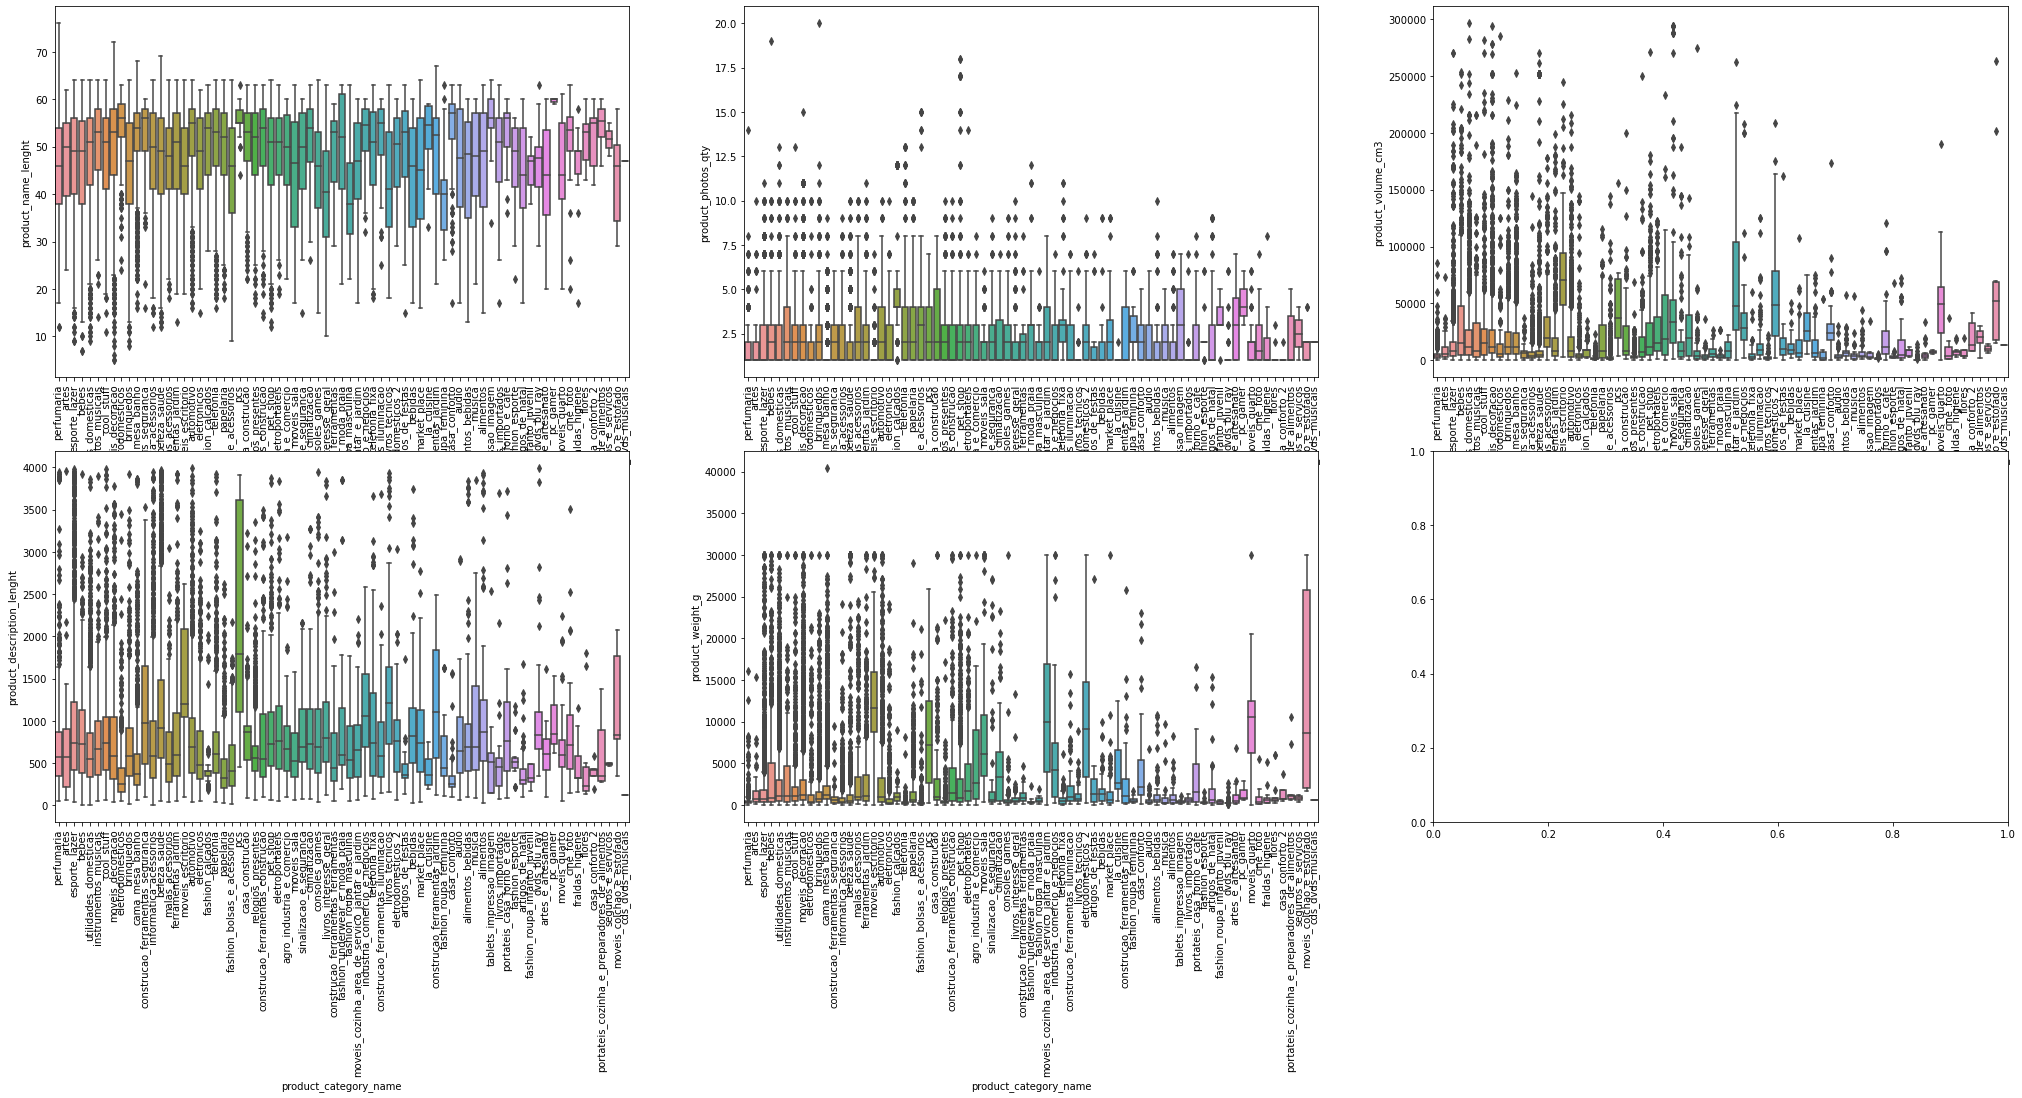

In [16]:
numeric_columns= ['product_name_lenght','product_description_lenght',
                  'product_photos_qty','product_weight_g','product_volume_cm3']
figure,axes = plt.subplots(2,3,figsize=(35,15))
for i in range(len(numeric_columns)) : 
    sns.boxplot(data = df_product_featured, 
                x='product_category_name',y= numeric_columns[i], ax = axes[i-2*int(i/2),int(i/2)])
    plt.sca(axes[i-2*int(i/2),int(i/2)])
    plt.xticks(rotation=90)
plt.show()

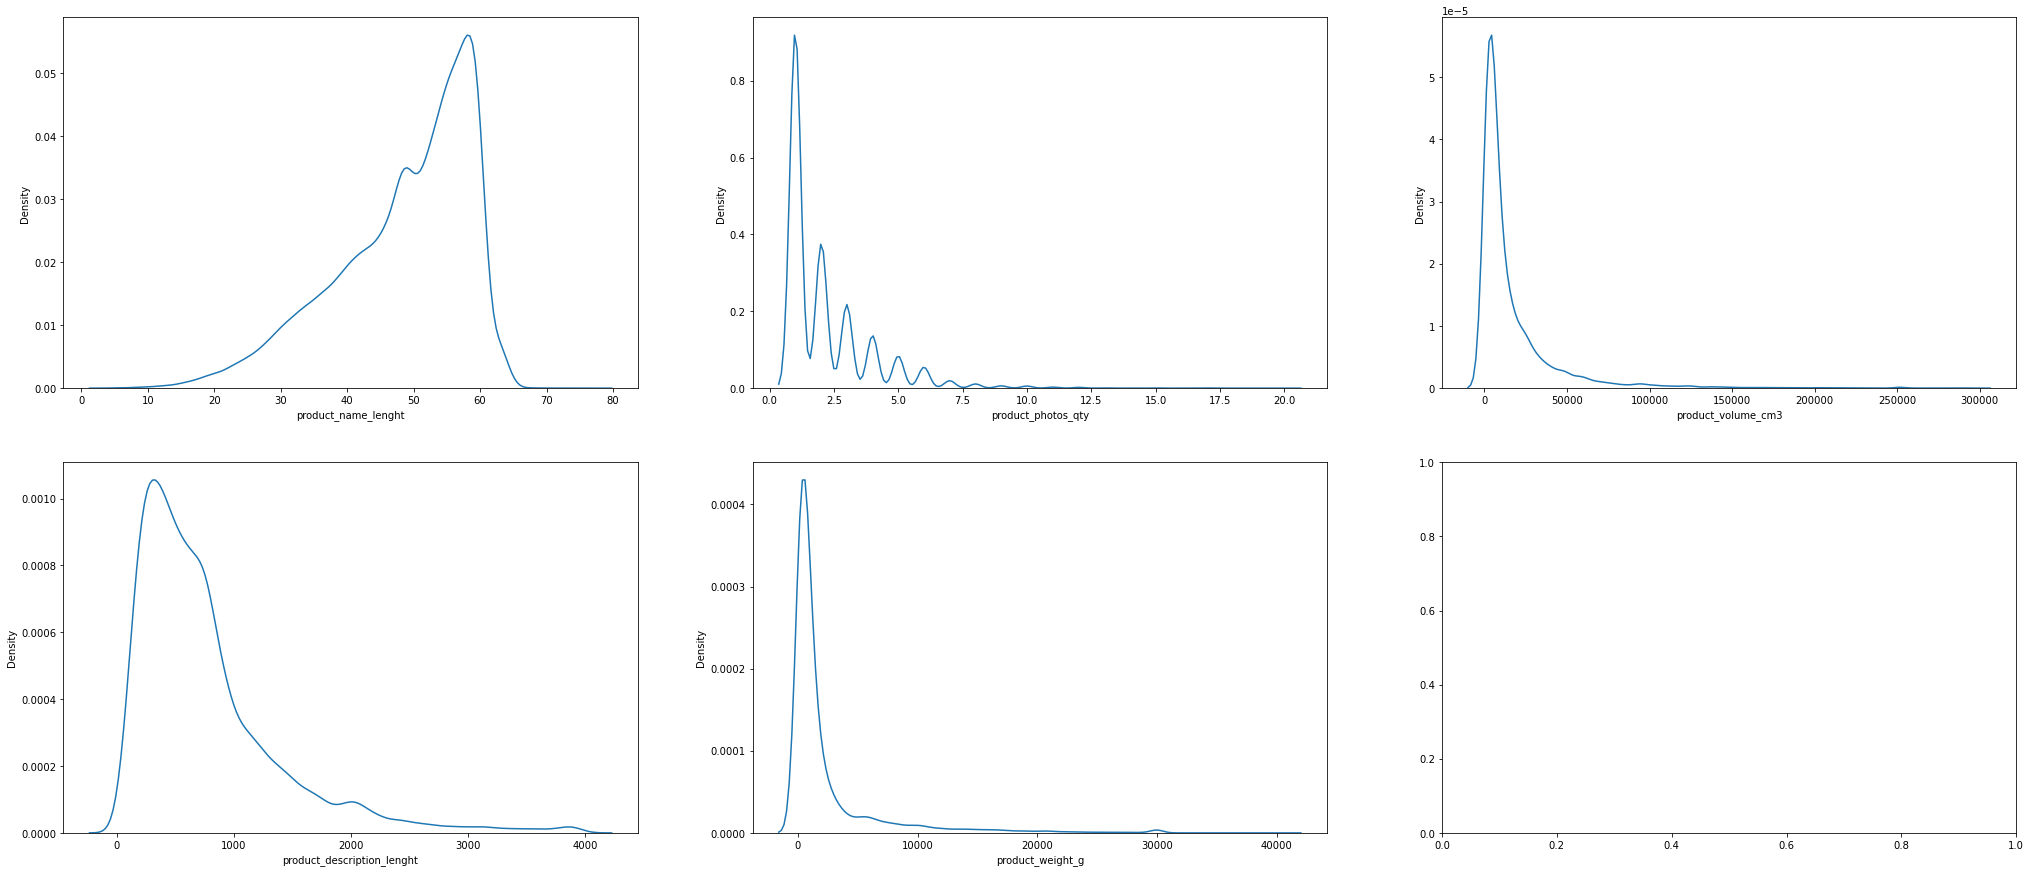

In [17]:
figure,axes = plt.subplots(2,3,figsize=(35,15))
for i in range(len(numeric_columns)) : 
    sns.kdeplot(data = df_product_featured, 
                x= numeric_columns[i], ax = axes[i-2*int(i/2),int(i/2)])

plt.show()

<a class="anchor" id="2.3"></a>
# **2.3 Fichier commandes** 

[Table des matières](#0.1)



In [18]:
print(df_order.shape)
df_order.head()

(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [19]:
df_order.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [20]:
df_order[df_order['order_delivered_customer_date'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


<a class="anchor" id="2.3.1"></a>
# **2.3.1 Sélection des commandes délivrées seulement** 

[Table des matières](#0.1)



In [21]:
df_order_delivered  = df_order[
    df_order['order_status']=='delivered'].drop(['order_status',
                                                 'order_delivered_carrier_date'],axis=1)
df_order_delivered.isna().sum()

order_id                          0
customer_id                       0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [22]:
df_order_delivered[df_order_delivered['order_approved_at'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,2017-02-18 14:40:00,NaN,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,2017-02-18 12:45:31,NaN,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,2017-02-18 13:29:47,NaN,2017-03-01 08:07:38,2017-03-17 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,2017-02-18 16:48:35,NaN,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,2017-02-17 13:05:55,NaN,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,2017-01-19 12:48:08,NaN,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,2017-02-19 01:28:47,NaN,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,2017-02-18 11:04:19,NaN,2017-03-02 16:15:23,2017-03-22 00:00:00
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,2017-01-19 22:26:59,NaN,2017-02-06 14:22:19,2017-03-16 00:00:00
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,2017-02-17 17:21:55,NaN,2017-03-03 12:16:03,2017-03-20 00:00:00


In [23]:
df_order_delivered[df_order_delivered['order_delivered_customer_date'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,2017-11-28 17:44:07,2017-11-28 17:56:40,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,2018-06-20 06:58:43,2018-06-20 07:19:05,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,2018-07-01 17:05:11,2018-07-01 17:15:12,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,2018-07-01 22:05:55,2018-07-01 22:15:14,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,2018-07-01 21:14:02,2018-07-01 21:29:54,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,2018-06-08 12:09:39,2018-06-08 12:36:39,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,2018-06-27 16:09:12,2018-06-27 16:29:30,NaN,2018-07-19 00:00:00


<a class="anchor" id="2.3.2"></a>
# **2.3.2 Remplissage des valeurs manquantes** 

[Table des matières](#0.1)



In [24]:
missing_approved_rows = df_order_delivered[df_order_delivered['order_approved_at'].isna()].index
for row in missing_approved_rows : 
    df_order_delivered.loc[row,'order_approved_at'] = df_order_delivered.loc[
                                                        row,'order_purchase_timestamp']    

In [25]:
col_date = ['order_purchase_timestamp', 'order_approved_at', 
            'order_delivered_customer_date', 'order_estimated_delivery_date']

df_order_delivered[col_date] = df_order_delivered[col_date].apply(pd.to_datetime, format='%Y-%m-%d %H:%M:%S.%f')

df_order_delivered[col_date].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 96478 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       96478 non-null  datetime64[ns]
 1   order_approved_at              96478 non-null  datetime64[ns]
 2   order_delivered_customer_date  96470 non-null  datetime64[ns]
 3   order_estimated_delivery_date  96478 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 5.7 MB


In [26]:

missing_delivered_rows = df_order_delivered[
    df_order_delivered['order_delivered_customer_date'].isna()].index
for row in missing_delivered_rows : 
    df_order_delivered.loc[row,'order_delivered_customer_date'] = df_order_delivered.loc[
                                                        row,'order_estimated_delivery_date'] + datetime.timedelta(days=1)

In [27]:
df_order_delivered.loc[missing_delivered_rows,'order_delivered_customer_date']

3002    2017-12-19
20618   2018-07-17
43834   2018-07-31
79263   2018-07-31
82868   2018-07-25
92643   2017-06-24
97647   2018-06-27
98038   2018-07-20
Name: order_delivered_customer_date, dtype: datetime64[ns]

In [28]:
df_order_delivered.isna().sum()

order_id                         0
customer_id                      0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

<a class="anchor" id="2.3.3"></a>
# **2.3.3 Gestion des valeurs temporelles** 

[Table des matières](#0.1)



In [29]:
df_order_delivered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 96478 entries, 0 to 99440
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   order_purchase_timestamp       96478 non-null  datetime64[ns]
 3   order_approved_at              96478 non-null  datetime64[ns]
 4   order_delivered_customer_date  96478 non-null  datetime64[ns]
 5   order_estimated_delivery_date  96478 non-null  datetime64[ns]
dtypes: datetime64[ns](4), object(2)
memory usage: 7.2+ MB


In [30]:
col_date = ['order_purchase_timestamp', 'order_approved_at', 
            'order_delivered_customer_date', 'order_estimated_delivery_date']

df_order_delivered[col_date] = df_order_delivered[col_date].apply(pd.to_datetime, format='%Y-%m-%d %H:%M:%S.%f')

df_order_delivered[col_date].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 96478 entries, 0 to 99440
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       96478 non-null  datetime64[ns]
 1   order_approved_at              96478 non-null  datetime64[ns]
 2   order_delivered_customer_date  96478 non-null  datetime64[ns]
 3   order_estimated_delivery_date  96478 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 5.7 MB


<a class="anchor" id="2.3.4"></a>
# **2.3.4 Création de la différence temporelle pour la validation du paiement et le temps de livraison** 

[Table des matières](#0.1)



In [31]:
import datetime
snapshot_date = max(df_order_delivered['order_purchase_timestamp']) + datetime.timedelta(days=1)
df_order_delivered['order_time_validation'] = (df_order_delivered[
    'order_approved_at']-df_order_delivered['order_purchase_timestamp']).dt.days
df_order_delivered['order_time_delivering'] = (df_order_delivered[
    'order_delivered_customer_date']-df_order_delivered['order_purchase_timestamp']).dt.days
df_order_delivered['order_purchase_date'] = df_order_delivered[
    'order_purchase_timestamp'].dt.strftime('%Y-%m')
df_order_delivered['order_estimation_diff'] = (df_order_delivered[
    'order_delivered_customer_date']-df_order_delivered['order_estimated_delivery_date']).apply(
    lambda x : x.days if x.days>0 else 0)
df_order_delivered['Recency']= (snapshot_date 
                                - df_order_delivered['order_purchase_timestamp']).dt.days

In [32]:
df_order_featured = df_order_delivered.drop([ 'order_approved_at', 'order_purchase_timestamp',
            'order_delivered_customer_date', 'order_estimated_delivery_date'],axis=1)
df_order_featured.head()

,order_id,customer_id,order_time_validation,order_time_delivering,order_purchase_date,order_estimation_diff,Recency
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,0,8,2017-10,0,332
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,1,13,2018-07,0,36
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,0,9,2018-08,0,22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,0,13,2017-11,0,284
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,0,2,2018-02,0,197


In [33]:
df_order_featured.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 96478 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   order_id               96478 non-null  object
 1   customer_id            96478 non-null  object
 2   order_time_validation  96478 non-null  int64 
 3   order_time_delivering  96478 non-null  int64 
 4   order_purchase_date    96478 non-null  object
 5   order_estimation_diff  96478 non-null  int64 
 6   Recency                96478 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 7.9+ MB


<a class="anchor" id="2.3.5"></a>
# **2.3.5 Analyse univariée** 

[Table des matières](#0.1)



/home/vortax/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/vortax/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


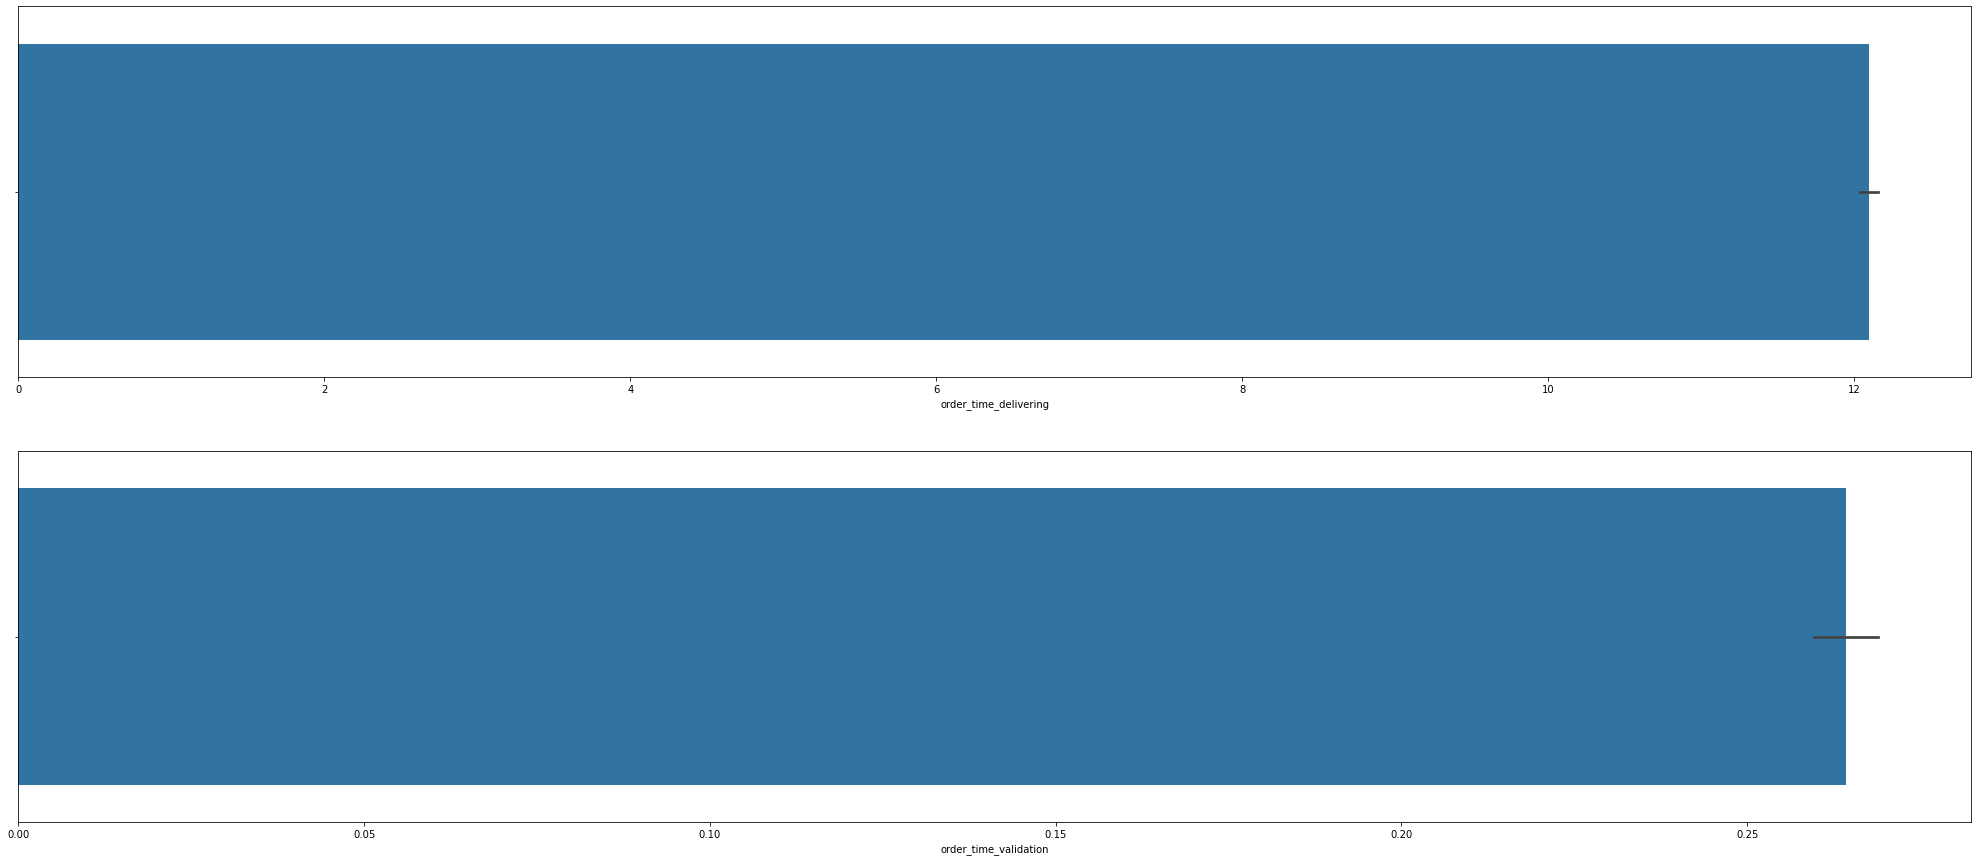

In [34]:
numeric_columns_order = ['order_time_delivering','order_time_validation']
figure,axes = plt.subplots(2,figsize=(35,15))
 
sns.barplot(df_order_featured[numeric_columns_order[0]], ax = axes[0])
sns.barplot(df_order_featured[numeric_columns_order[1]], ax = axes[1])
plt.show()

<a class="anchor" id="2.4"></a>
# **2.4 Fichier paiements** 
[Table of Contents](#0.1)


In [35]:
print(df_payment.shape)
df_payment.head()

(103886, 5)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [36]:
df_payment.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

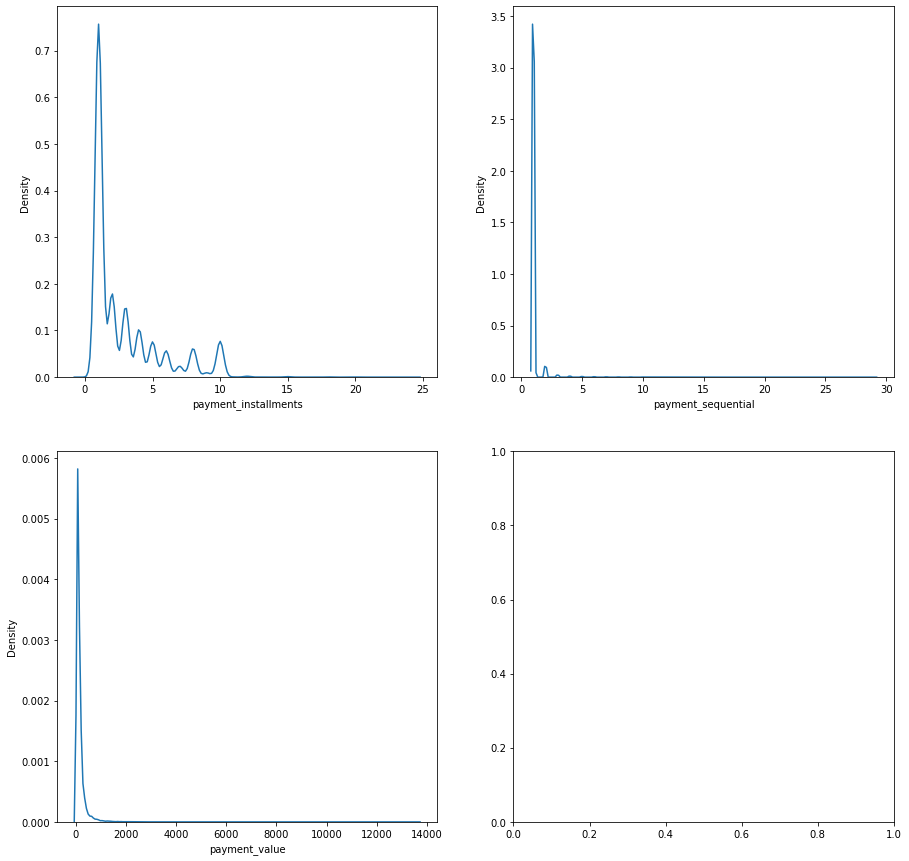

In [37]:
figure,axes = plt.subplots(2,2,figsize=(15,15))
sns.kdeplot(data=df_payment,x='payment_installments',ax=axes[0,0])
sns.kdeplot(data=df_payment,x='payment_value',ax=axes[1,0])
sns.kdeplot(data=df_payment,x='payment_sequential',ax=axes[0,1])
plt.show()

In [38]:
df_payment.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


<a class="anchor" id="2.5"></a>
# **2.5 Fichier retour clients** 

[Table of Contents](#0.1)


In [39]:
print(df_review.shape)
df_review.head()

(99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [40]:
df_review.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

<a class="anchor" id="2.5.1"></a>
# **2.5.1 Suppression de parmètres et transformation en données temporelles** 

[Table of Contents](#0.1)


In [41]:
df_review_dropped=df_review.drop(['review_comment_title','review_comment_message'],axis=1)
df_review_dropped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_creation_date     99224 non-null  object
 4   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [42]:
review_date_columns = ['review_creation_date','review_answer_timestamp']
df_review_dropped[review_date_columns]  = df_review_dropped[review_date_columns
                                                           ].apply(
                                            pd.to_datetime,format = '%Y-%m-%d %H:%M:%S.%f')
df_review_dropped.info()                   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_creation_date     99224 non-null  datetime64[ns]
 4   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 3.8+ MB


<a class="anchor" id="2.5.2"></a>
# **2.5.2 Nettoyages des retours sur les mêmes commandes** 

[Table of Contents](#0.1)


In [43]:
list_duplicated_review = list(df_review_dropped[df_review_dropped.duplicated('order_id')].order_id)
df_review_dropped[df_review_dropped['order_id'].isin(list_duplicated_review)]

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
30,540e7bbb2d06cfb7f85f3a88ba7ac97f,cf73e2cb1f4a9480ed70c154da3d954a,5,2018-01-18,2018-01-18 19:12:30
344,a0a641414ff718ca079b3967ef5c2495,169d7e0fd71d624d306f132acd791cbe,5,2018-03-04,2018-03-06 20:12:53
498,505a882ba08a689682a4afc6eb4e5965,1c308eca3f339414a92e518e2a2e5ee9,2,2017-12-28,2017-12-31 20:25:02
764,c5976a5a98e854fb23d7e03c6754ae60,2002ea16e75277eaa0b5d78632048540,5,2017-08-08,2017-08-10 11:11:29
778,62c7722239b976d943ec0d430cfe890e,1d297b4800ed1a3c5b0944d84c01ee99,3,2017-10-22,2017-10-31 15:33:32
...,...,...,...,...,...
98989,dfb3db02188d809d5cd199496b6da87e,c0db7d31ace61fc360a3eaa34dd3457c,5,2018-02-17,2018-02-19 19:29:19
99108,2c6c08892b83ba4c1be33037c2842294,42ae1967f68c90bb325783ac55d761ce,4,2017-07-03,2017-07-05 19:06:59
99164,2afe63a67dfd99b3038f568fb47ee761,c5334d330e36d2a810a7a13c72e135ee,5,2018-03-03,2018-03-04 22:56:47
99178,44d1e9165ec54b1d89d33594856af859,a7dbcf5043158d6fa72859eead2f3d10,4,2017-05-24,2017-05-24 23:15:21


In [44]:
df_review_dropped = df_review_dropped.drop_duplicates('order_id')

<a class="anchor" id="2.5.3"></a>
# **2.5.3 Création du feature temps de réponse** 

[Table of Contents](#0.1)


In [45]:
df_review_dropped['review_delta'] = (df_review_dropped['review_answer_timestamp']-df_review_dropped[
    'review_creation_date']).dt.days
df_review_dropped.head()

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,review_delta
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59,0
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13,1
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24,1
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06,0
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53,1


<a class="anchor" id="2.5.4"></a>
# **2.5.4 Analyse univariée** 

[Table of Contents](#0.1)


<AxesSubplot:xlabel='review_score', ylabel='Density'>

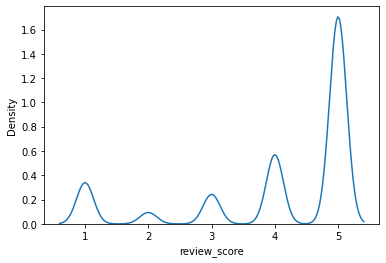

In [46]:
df_review_featured = df_review_dropped.drop(['review_creation_date',
     'review_answer_timestamp'],axis=1)
sns.kdeplot(data = df_review_featured,x = 'review_score')

<a class="anchor" id="2.6"></a>
# **2.6 Fichier objet** 

[Table of Contents](#0.1)


In [47]:
print(df_item.shape)
df_item.head()

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [48]:
df_item.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

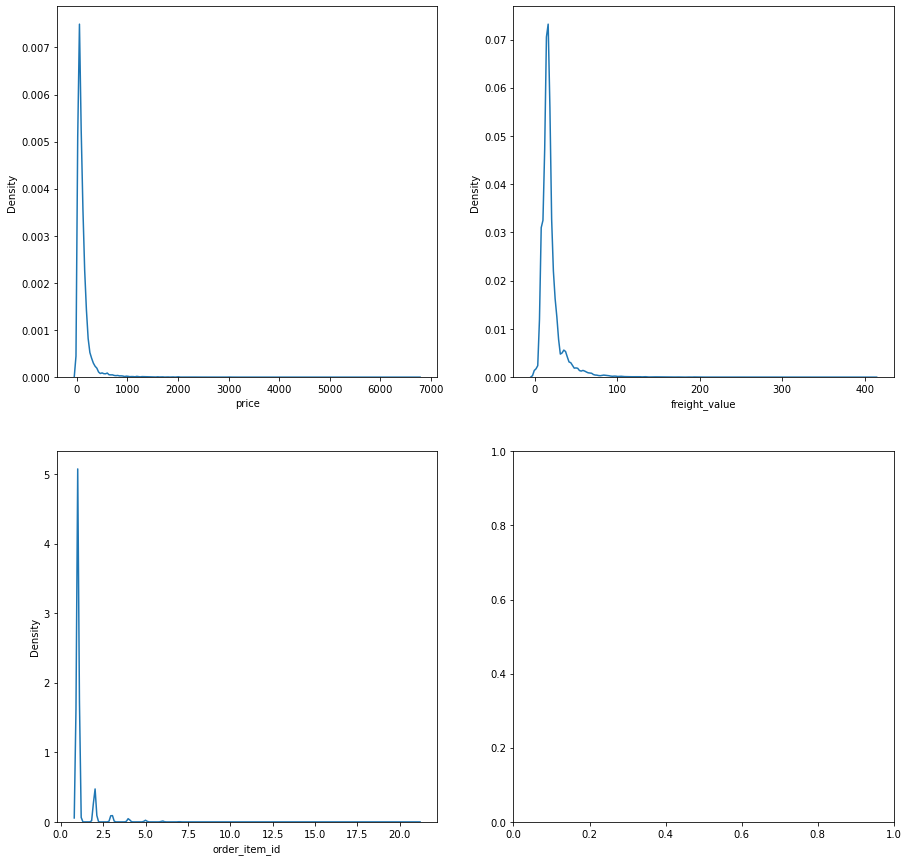

In [49]:
df_item_dropped = df_item.drop(['seller_id','shipping_limit_date'],axis=1)
figure,axes = plt.subplots(2,2,figsize=(15,15))
sns.kdeplot(data = df_item_dropped,x='price',ax=axes[0,0])
sns.kdeplot(data = df_item_dropped,x='freight_value',ax=axes[0,1])
sns.kdeplot(data = df_item_dropped,x='order_item_id',ax=axes[1,0] )
plt.show()

<a class="anchor" id="3"></a>
# **3. Préparation de notre DataFrame** 

[Table of Contents](#0.1)


# **3.1 Jointure en un DataFrame** <a class="anchor" id="3.1"></a>

[Table of Contents](#0.1)


Chaque fichier à plusieurs colonnes dont certainnes sont similaires chez certains. Celles-ci  seront nos clés primaires : 
 - 'customer_id' commun à df_order et df_customer
 - 'order_id commun à df_order, df_item,df_payment et df_review
 - 'product_id' commun à df_product et df_item
 -  commun à df_item 
 - 'product_category_name' commun à df_category et df_product
 
 Nous allons ainsi faire nos jointure de ces différents fichiers de données pour les regrouper dans un seul DataFrame. 

In [69]:
data = pd.DataFrame()
data = df_order_featured.merge(df_customer_dropped, on='customer_id', how='left')
data = data.merge(df_item_dropped, on='order_id', how='left')
data = data.merge(df_review_featured, on='order_id', how='inner')
data = data.merge(df_product_featured, on='product_id', how='inner')
data = data.merge(df_category, on='product_category_name', how='left')
data = data.merge(df_payment, on='order_id', how='inner')
print(data.columns)
print(data.shape)
data.head()

Index(['order_id', 'customer_id', 'order_time_validation',
       'order_time_delivering', 'order_purchase_date', 'order_estimation_diff',
       'Recency', 'customer_unique_id', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'price', 'freight_value', 'review_id',
       'review_score', 'review_delta', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_volume_cm3',
       'product_category_name_english', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
(114155, 28)


,order_id,customer_id,order_time_validation,order_time_delivering,order_purchase_date,order_estimation_diff,Recency,customer_unique_id,customer_city,customer_state,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_volume_cm3,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,0,8,2017-10,0,332,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,...,40.0,268.0,4.0,500.0,1976.0,housewares,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,0,8,2017-10,0,332,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,...,40.0,268.0,4.0,500.0,1976.0,housewares,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,0,8,2017-10,0,332,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,...,40.0,268.0,4.0,500.0,1976.0,housewares,2,voucher,1,18.59
3,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,0,2,2017-08,0,379,3a51803cc0d012c3b5dc8b7528cb05f7,sao paulo,SP,...,40.0,268.0,4.0,500.0,1976.0,housewares,1,credit_card,3,37.77
4,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,0,5,2017-08,0,392,ef0996a1a279c26e7ecbd737be23d235,sao paulo,SP,...,40.0,268.0,4.0,500.0,1976.0,housewares,1,credit_card,1,37.77


<a class="anchor" id="3.2"></a>
# **3.2 Gestion des valeurs manquantes** 
[Table of Contents](#0.1)


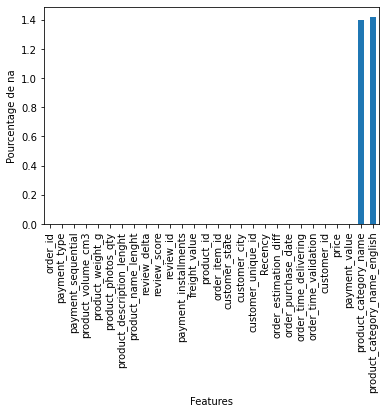

In [74]:
list_na = data.isna().sum()/len(data)*100
list_na_sorted = list_na.sort_values()
list_na_sorted.plot.bar()
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Pourcentage de na')
plt.show()

In [52]:
data.drop(['product_category_name','customer_id','review_id'],axis=1,inplace=True)
data['product_category_name_english'] = data['product_category_name_english'].fillna('other')
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 114155 entries, 0 to 114154
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114155 non-null  object 
 1   order_time_validation          114155 non-null  int64  
 2   order_time_delivering          114155 non-null  int64  
 3   order_purchase_date            114155 non-null  object 
 4   order_estimation_diff          114155 non-null  int64  
 5   Recency                        114155 non-null  int64  
 6   customer_unique_id             114155 non-null  object 
 7   customer_city                  114155 non-null  object 
 8   customer_state                 114155 non-null  object 
 9   order_item_id                  114155 non-null  int64  
 10  product_id                     114155 non-null  object 
 11  price                          114155 non-null  float64
 12  freight_value                 

 <a class="anchor" id="3.3"></a>
# **3.3 Aggrégation des différentes commandes pour chaque client**
[Table of Contents](#0.1)


In [53]:
data_unique_order= data.groupby(['customer_unique_id','order_id']).agg(
    {'price':'sum','freight_value':'sum','product_photos_qty':'mean','review_score':'mean',
     'product_id':'count','product_weight_g' : 'mean','payment_type':'nunique',
     'product_name_lenght':'mean','product_description_lenght' : 'mean',
     'product_volume_cm3':'mean','payment_value':'sum','payment_installments':'sum',
      'order_time_validation' :'mean','order_time_delivering':'mean',
     'review_delta': 'mean','Recency' : 'min','order_estimation_diff':'mean'
    })
data_unique_order.reset_index(inplace=True)
data_unique_order.head(5)

,customer_unique_id,order_id,price,freight_value,product_photos_qty,review_score,product_id,product_weight_g,payment_type,product_name_lenght,product_description_lenght,product_volume_cm3,payment_value,payment_installments,order_time_validation,order_time_delivering,review_delta,Recency,order_estimation_diff
0,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,129.90,12.00,1.0,5.0,1,1500.0,1,60.0,236.0,7616.0,141.90,8,0.0,6.0,4.0,112,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,18.90,8.29,1.0,4.0,1,375.0,1,56.0,635.0,5148.0,27.19,1,0.0,3.0,0.0,115,0.0
2,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,69.00,17.22,3.0,3.0,1,1500.0,1,49.0,177.0,43750.0,86.22,8,0.0,25.0,1.0,537,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,25.99,17.63,5.0,4.0,1,150.0,1,43.0,1741.0,1045.0,43.62,4,0.0,20.0,1.0,321,0.0
4,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,180.00,16.89,3.0,5.0,1,6050.0,1,58.0,794.0,528.0,196.89,6,0.0,13.0,4.0,288,0.0


In [54]:
data[data['customer_unique_id']=='7c396fd4830fd04220f754e42b4e5bff']

,order_id,order_time_validation,order_time_delivering,order_purchase_date,order_estimation_diff,Recency,customer_unique_id,customer_city,customer_state,order_item_id,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_volume_cm3,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,0,8,2017-10,0,332,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,...,40.0,268.0,4.0,500.0,1976.0,housewares,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,0,8,2017-10,0,332,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,...,40.0,268.0,4.0,500.0,1976.0,housewares,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,0,8,2017-10,0,332,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,...,40.0,268.0,4.0,500.0,1976.0,housewares,2,voucher,1,18.59
22746,69923a4e07ce446644394df37a710286,0,1,2017-09,0,360,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,...,35.0,2395.0,1.0,350.0,3192.0,baby,1,credit_card,1,44.11


In [64]:
data_unique_customer= data_unique_order.groupby(['customer_unique_id']).agg(
    {'price':'sum','freight_value':'sum','product_photos_qty':'mean','review_score':'mean',
     'product_id':'mean','product_weight_g' : 'mean','payment_type':'mean',
     'product_name_lenght':'mean','product_description_lenght' : 'mean',
     'product_volume_cm3':'mean','payment_value':'sum','payment_installments':'mean',
     'order_id':'count','order_time_validation' :'mean','order_time_delivering':'mean',
     'review_delta': 'mean','Recency':'min','order_estimation_diff':'mean'})
data_unique_customer = data_unique_customer.rename(columns={"payment_value": "Total_payment_value",
                                     "freight_value": "Total_freight_value",
                                    "price" : "Total_price",
                                    "product_id" : "Mean_product_ordered",
                                    "order_id" : 'Total_order'})
data_unique_customer.head(5)

,Total_price,Total_freight_value,product_photos_qty,review_score,Mean_product_ordered,product_weight_g,payment_type,product_name_lenght,product_description_lenght,product_volume_cm3,Total_payment_value,payment_installments,Total_order,order_time_validation,order_time_delivering,review_delta,Recency,order_estimation_diff
customer_unique_id,,,,,,,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,129.90,12.00,1.0,5.0,1.0,1500.0,1.0,60.0,236.0,7616.0,141.90,8.0,1,0.0,6.0,4.0,112,0.0
0000b849f77a49e4a4ce2b2a4ca5be3f,18.90,8.29,1.0,4.0,1.0,375.0,1.0,56.0,635.0,5148.0,27.19,1.0,1,0.0,3.0,0.0,115,0.0
0000f46a3911fa3c0805444483337064,69.00,17.22,3.0,3.0,1.0,1500.0,1.0,49.0,177.0,43750.0,86.22,8.0,1,0.0,25.0,1.0,537,0.0
0000f6ccb0745a6a4b88665a16c9f078,25.99,17.63,5.0,4.0,1.0,150.0,1.0,43.0,1741.0,1045.0,43.62,4.0,1,0.0,20.0,1.0,321,0.0
0004aac84e0df4da2b147fca70cf8255,180.00,16.89,3.0,5.0,1.0,6050.0,1.0,58.0,794.0,528.0,196.89,6.0,1,0.0,13.0,4.0,288,0.0


In [56]:
data_unique_customer.loc['7c396fd4830fd04220f754e42b4e5bff']

price                          125.36
freight_value                   34.88
product_photos_qty               2.50
review_score                     4.50
product_id                       2.00
product_weight_g               425.00
payment_type                     1.50
product_name_lenght             37.50
product_description_lenght    1331.50
product_volume_cm3            2584.00
payment_value                   82.82
payment_installments             2.00
order_id                         2.00
order_time_validation            0.00
order_time_delivering            4.50
review_delta                     1.00
Recency                        332.00
order_estimation_diff            0.00
Name: 7c396fd4830fd04220f754e42b4e5bff, dtype: float64

 <a class="anchor" id="3.4"></a>
# **3.4 Analyse exploratoire**
[Table of Contents](#0.1)


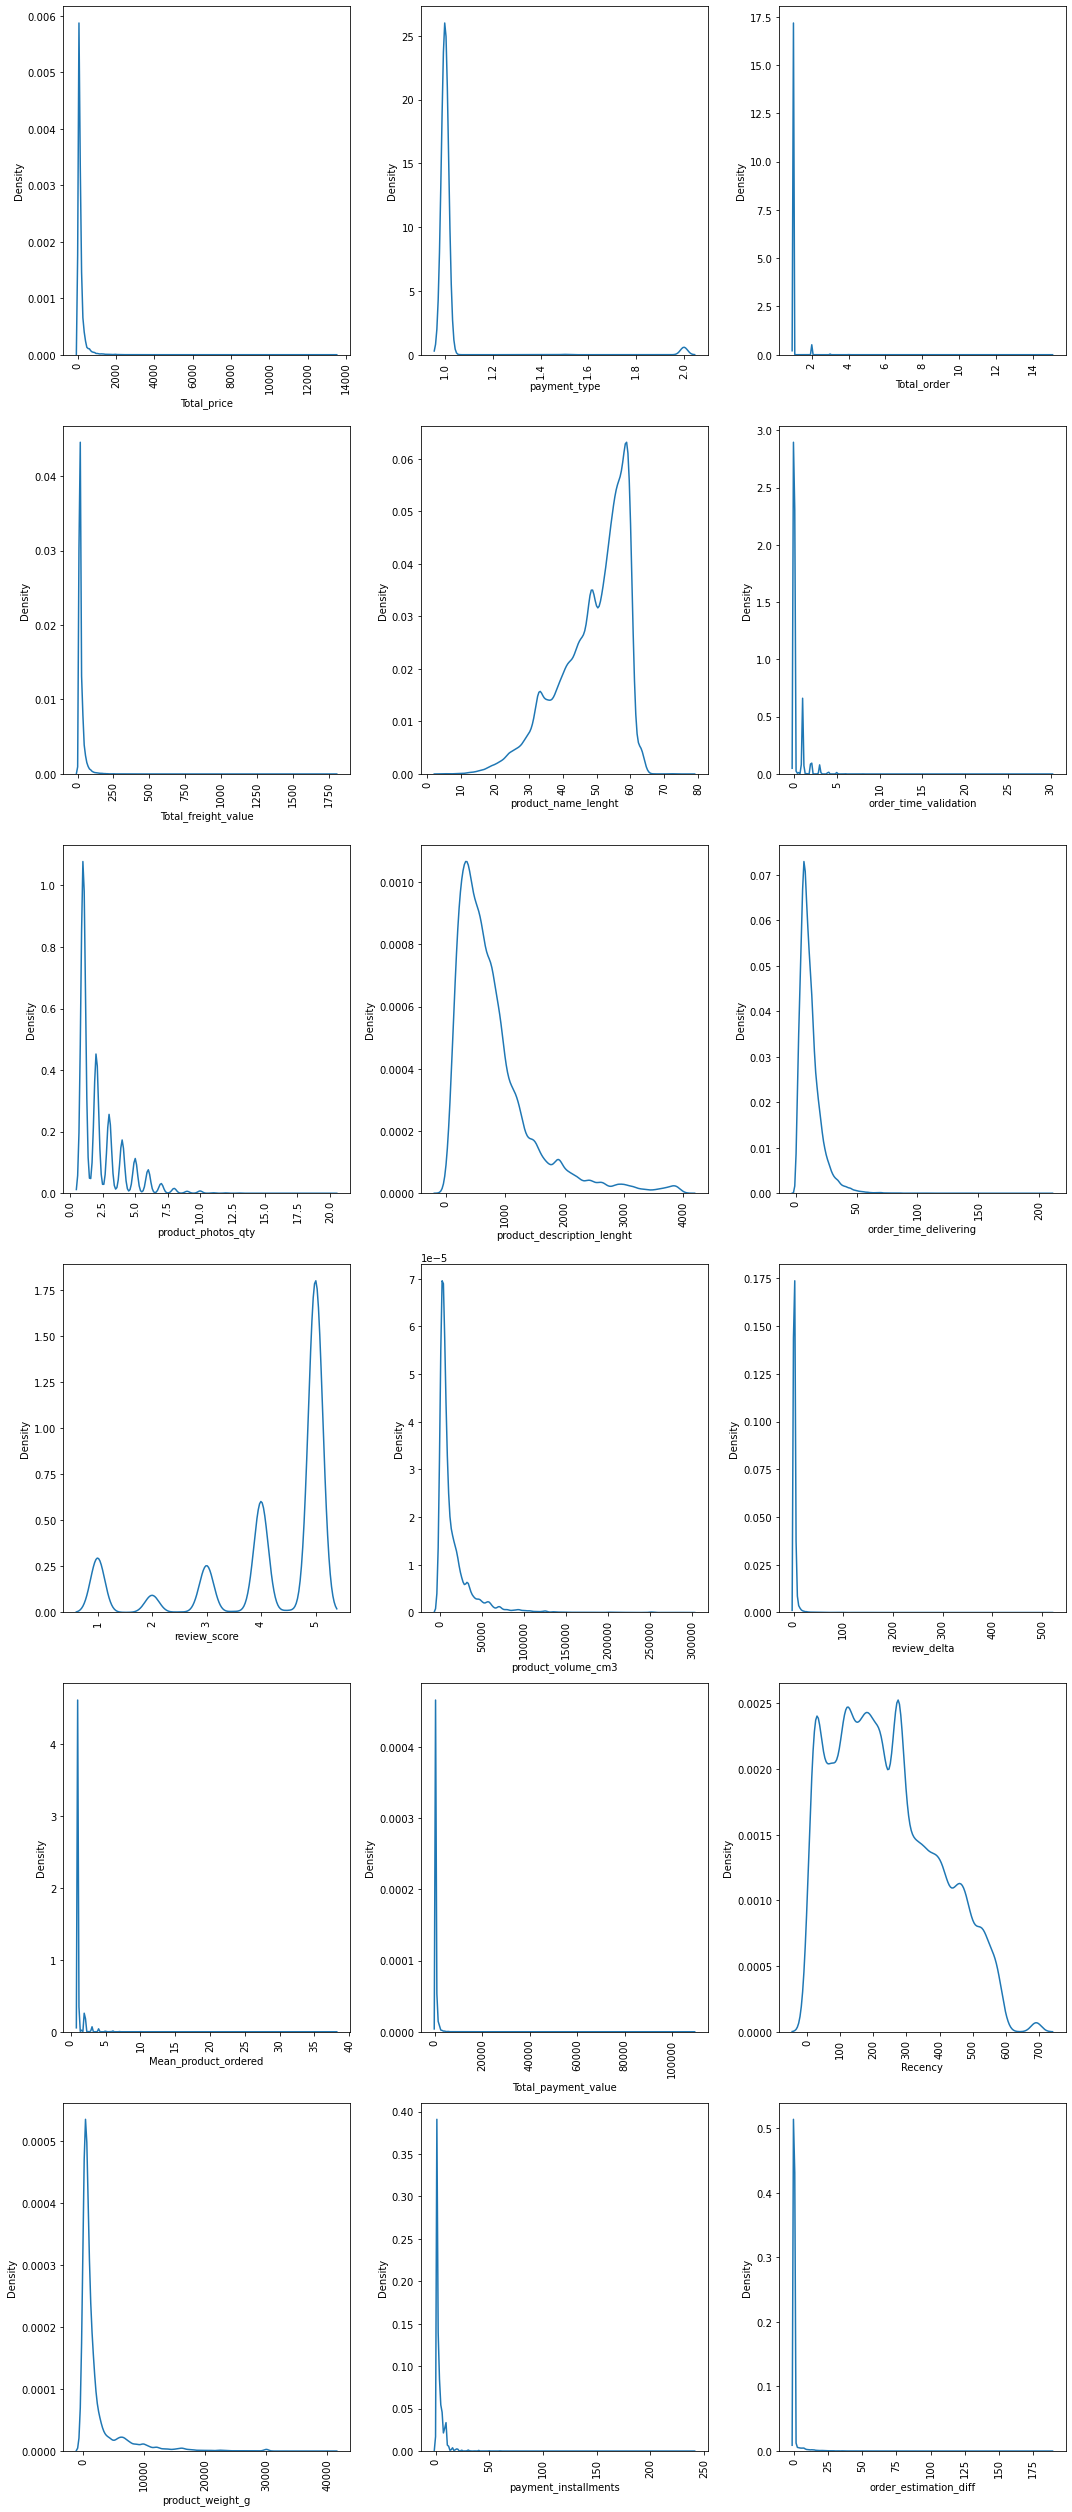

In [77]:
study_columns= data_unique_customer.columns
figure,axes = plt.subplots(6,3,figsize=(15,35))
for i in range(len(study_columns)) : 
    sns.kdeplot(data = data_unique_customer, 
                x= study_columns[i], ax = axes[i-6*int(i/6),int(i/6)])
    plt.sca(axes[i-6*int(i/6),int(i/6)])
    plt.xticks(rotation=90)
figure.tight_layout()
plt.show()

<AxesSubplot:>

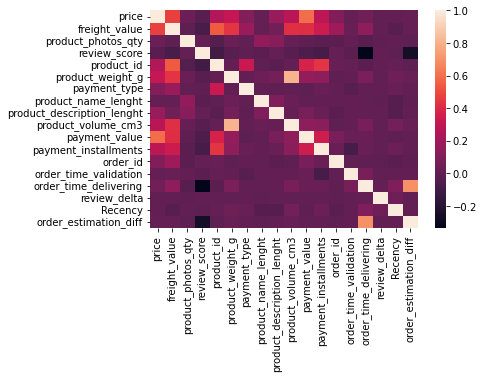

In [58]:
sns.heatmap(data = data_unique_customer.corr() )

<AxesSubplot:xlabel='product_volume_cm3', ylabel='product_weight_g'>

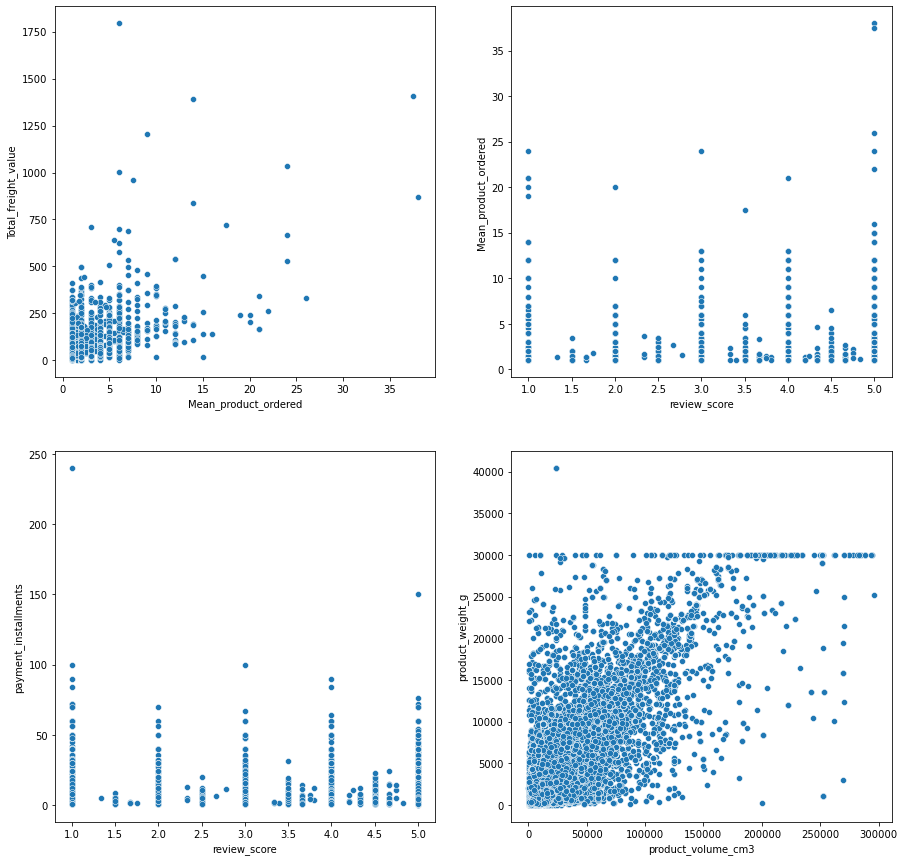

In [65]:
figure,axes = plt.subplots(2,2,figsize=(15,15))
sns.scatterplot(data = data_unique_customer , x = 'Mean_product_ordered', y = 'Total_freight_value',
                ax = axes[0,0])
sns.scatterplot(data = data_unique_customer , y = 'payment_installments', x = 'review_score',
                ax = axes[1,0])
sns.scatterplot(data = data_unique_customer , y = 'Mean_product_ordered', x = 'review_score',
                ax = axes[0,1])
sns.scatterplot(data = data_unique_customer , y = 'product_weight_g', x = 'product_volume_cm3',
                ax = axes[1,1])

<AxesSubplot:xlabel='product_volume_cm3', ylabel='product_weight_g'>

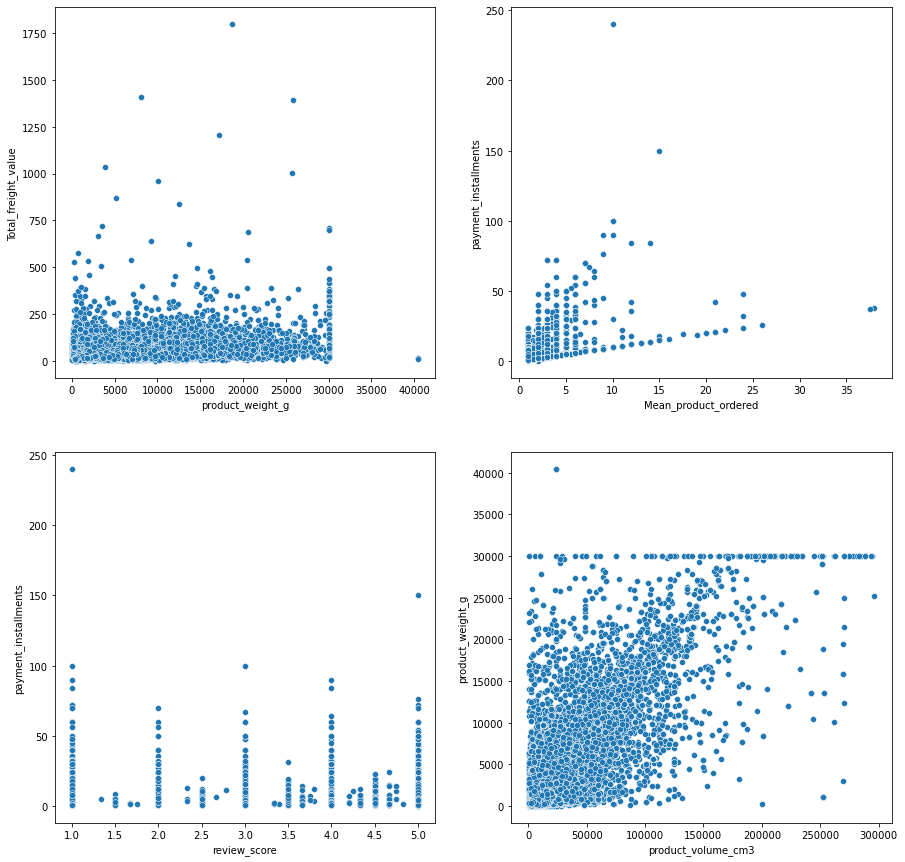

In [66]:
figure,axes = plt.subplots(2,2,figsize=(15,15))
sns.scatterplot(data = data_unique_customer , x = 'product_weight_g', y = 'Total_freight_value',
                ax = axes[0,0])
sns.scatterplot(data = data_unique_customer , y = 'payment_installments', x = 'review_score',
                ax = axes[1,0])
sns.scatterplot(data = data_unique_customer , y = 'payment_installments', x = 'Mean_product_ordered',
                ax = axes[0,1])
sns.scatterplot(data = data_unique_customer , y = 'product_weight_g', x = 'product_volume_cm3',
                ax = axes[1,1])

In [62]:
data_unique_customer.to_csv('Olist.csv')
data.to_csv('Olist_explore.csv')

[Retour en haut](#0)